In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle
import shap
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../../Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [3]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2008-2019_Cases_Dates.txt", "r")
print(f.read())

path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv'

data = read_data(path)
data.head()

months: 6, 7, 8, 9, 10, 11, 
years: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 


,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,19349,46.86670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
1,12.04199,45.06525,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,20233,46.64640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.0,1.206604,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,2297,46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,1,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,3400,46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
4,12.04755,46.30297,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,4249,47.84463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,1,0,0


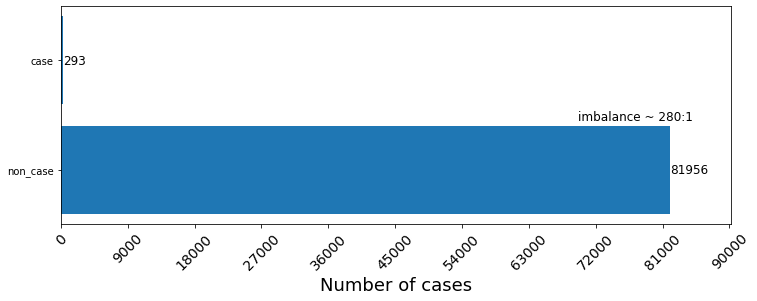

In [4]:
plot_imbalance(data.query('month >= 5 & month <= 10'))

In [5]:
dataset = data.query('month >= 6 & month <= 10 & year >= 2010')
dataset.reset_index(inplace=True, drop=True)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2010-06-01,veneto,abano terme,1,6,22,2010,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,19349,46.86670,0.450494,0.178472,-0.258050,-0.178472,0.378067,0.112795,-0.261900,-0.112795,0.053075,0.041897,0.017151,0.041897,22.860,28.910,16.81,5.096667,-1.246667,7.950000,0.696667,13.300000,2.857143,24.255263,9.739231,51.616934,53.162035,941.517910,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,315,380,0
1,12.04199,45.06525,2010-06-01,veneto,adria,1,6,22,2010,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,20233,46.64640,NaN,NaN,NaN,NaN,0.369729,0.131875,-0.204825,-0.131875,0.078332,0.005067,0.076738,0.005067,20.754,29.038,12.47,3.184190,-1.703200,6.985636,-0.136362,14.502667,2.184644,23.560450,8.161343,37.376842,38.216803,965.097941,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.0,1.206604,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,480,274,0
2,10.77673,45.55680,2010-06-01,veneto,affi,1,6,22,2010,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,2297,46.81410,0.385195,0.114683,-0.284752,-0.114683,0.406715,0.126653,-0.291818,-0.126653,0.077602,0.035532,0.041629,0.035532,21.460,29.110,13.81,3.893636,-3.047778,8.201111,-1.084000,13.662857,2.460000,21.922000,7.837778,95.744077,97.903274,879.362470,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,92.0,20.0,92.0,20.0,92.0,9,9.0,4.0,1.0,1.0,2,0,41,76,0
3,11.96539,45.17531,2010-06-01,veneto,agna,1,6,22,2010,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,3400,46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.080,29.470,12.69,3.743333,-1.620000,6.286000,-1.410000,13.685556,1.691667,23.484118,8.180588,50.679072,51.004160,958.164236,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,98.0,36.0,99.0,30.0,98.0,12,12.0,1.0,6.0,7.0,2,0,457,398,0
4,12.04755,46.30297,2010-06-01,veneto,agordo,1,6,22,2010,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,4249,47.84463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,94.0,10.0,94.0,10.0,94.0,5,5.0,7.0,1.0,1.0,2,0,32,49,0


In [6]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment', 'lc_prop2',
       'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc

In [7]:
print(f'LAU1 Units: {dataset.lau1.unique().shape[0]}')

LAU1 Units: 571


In [8]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,5703,7,5710,10.00%
1,2011,5699,11,5710,10.00%
2,2012,5679,34,5713,10.00%
3,2013,5682,29,5711,10.00%
4,2014,5708,2,5710,10.00%
5,2015,5709,1,5710,10.00%
6,2016,5698,12,5710,10.00%
7,2017,5694,17,5711,10.00%
8,2018,5592,136,5728,10.03%
9,2019,5675,37,5712,10.00%


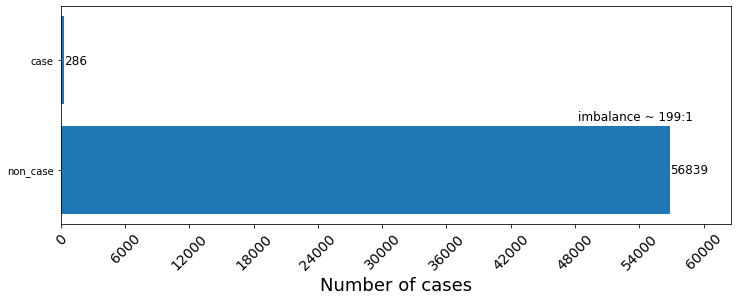

In [9]:
plot_imbalance(dataset)

In [10]:
majority_class = 0
near_u = 0.3
smote = 0.7
scaler = 'minmax'
weight_multiplier = 2
years_to_remove = [2008, 2014, 2015]
years_to_remove = []

features_to_remove = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 
                      'lc_prop1_assessment','lc_prop2_assessment','lc_prop3_assessment',
                      'lw', 'qc','lc_type1', 'lc_type3', 'lc_type4', 'lc_type5',]

#features_to_remove = []


In [11]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                        + features_to_remove).columns

print(feature_names)

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'population',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river',
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km',
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'lc_prop1',
       'lc_prop2', 'lc_prop3', 'lc_type2', 'mosq_pred', 'mosq_previous'],
      dtype='object')


In [12]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler, majority_class, features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:152 || ##
Year: 2011 || w0:1, w1:154 || ##
Year: 2012 || w0:1, w1:168 || ##
Year: 2013 || w0:1, w1:164 || ##
Year: 2014 || w0:1, w1:150 || ##
Year: 2015 || w0:1, w1:148 || ##
Year: 2016 || w0:1, w1:154 || ##
Year: 2017 || w0:1, w1:158 || ##
Year: 2018 || w0:1, w1:282 || ##
Year: 2019 || w0:1, w1:170 || ##


In [13]:
feature_names

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'population',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river',
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km',
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'lc_prop1',
       'lc_prop2', 'lc_prop3', 'lc_type2', 'mosq_pred', 'mosq_previous'],
      dtype='object')

In [14]:
len(feature_names)

46

In [15]:
indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi',
            'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
            'ndvi_std','ndmi_std', 'ndwi_std', 'ndbi_std',]

temperature = ['lst', 'lst_day', 'lst_night',
               'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
               'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
               'lst_apr_day_mean', 'lst_apr_night_mean',]

rainfall = ['acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',]

demographic = ['area', 'population', 'population_density',]

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',]

spatiotemporal = ['month_sin', 'month_cos', 'week_sin', 'week_cos','eq_distance',]

entomological = ['mosq_pred', 'mosq_previous']

In [16]:
len(indicies+temperature+rainfall+demographic+geomorphological+spatiotemporal+entomological)

48

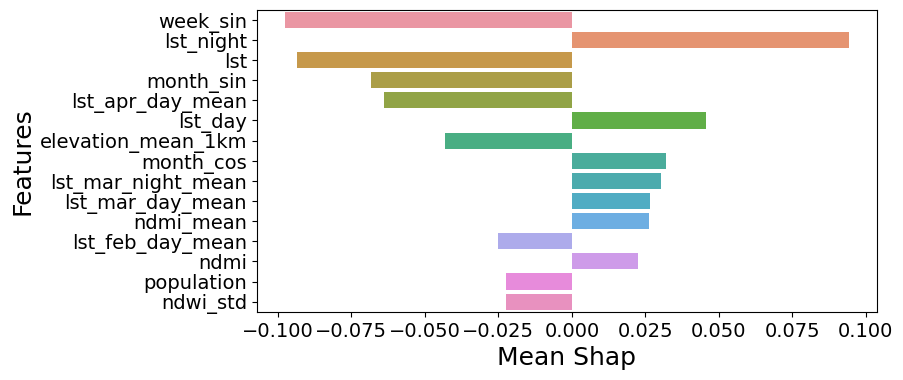

In [17]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

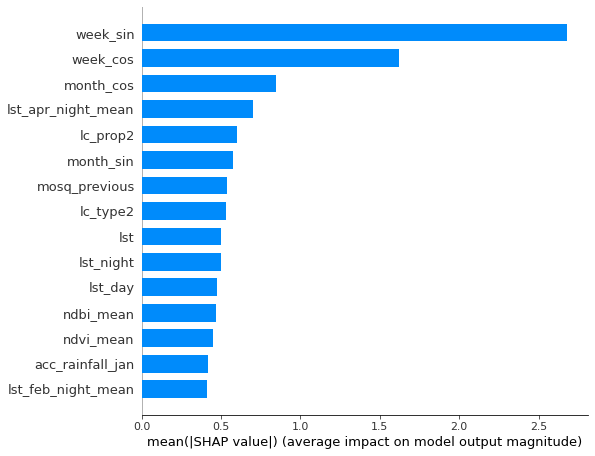

In [18]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

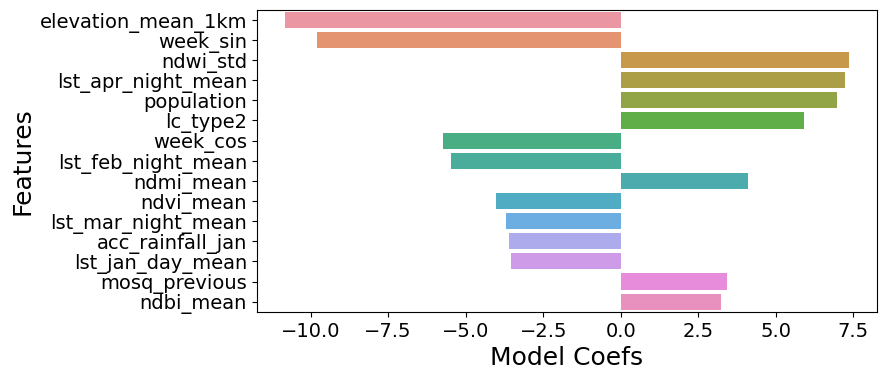

In [19]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

In [20]:
coefs

,features,weights
36,elevation_mean_1km,-10.827670
2,week_sin,-9.808390
16,ndwi_std,7.347609
28,lst_apr_night_mean,7.227008
4,population,6.959457
43,lc_type2,5.904924
3,week_cos,-5.720949
24,lst_feb_night_mean,-5.461944
11,ndmi_mean,4.103744
10,ndvi_mean,-4.033659


In [21]:
shaps

,features,weights,weights_abs
2,week_sin,-0.097574,0.097574
20,lst_night,0.094104,0.094104
18,lst,-0.093579,0.093579
0,month_sin,-0.068225,0.068225
27,lst_apr_day_mean,-0.063926,0.063926
19,lst_day,0.045719,0.045719
36,elevation_mean_1km,-0.043029,0.043029
1,month_cos,0.032142,0.032142
26,lst_mar_night_mean,0.030217,0.030217
25,lst_mar_day_mean,0.026414,0.026414


,features,weights
5,spatiotemporal,0.041640
1,temperature,0.037361
3,demographic,0.022305
0,indicies,0.013666
4,geomorphological,0.008530
6,entomological,0.005449
2,rainfall,0.002941


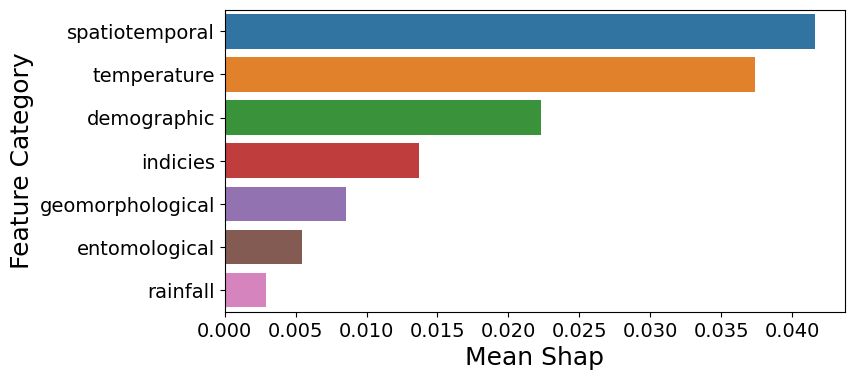

In [22]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_temperature = shaps.loc[shaps['features'].isin(temperature)].drop(columns=['weights'])
df_rainfall = shaps.loc[shaps['features'].isin(rainfall)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_entomological = shaps.loc[shaps['features'].isin(entomological)].drop(columns=['weights'])

categories = {'Category': ['indicies', 'temperature', 'rainfall', 'demographic', 'geomorphological', 'spatiotemporal', 'entomological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_temperature.weights_abs.mean(),df_rainfall.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_entomological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

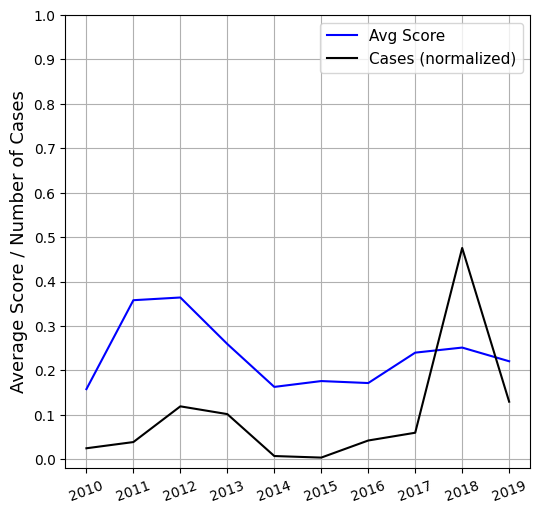

In [23]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

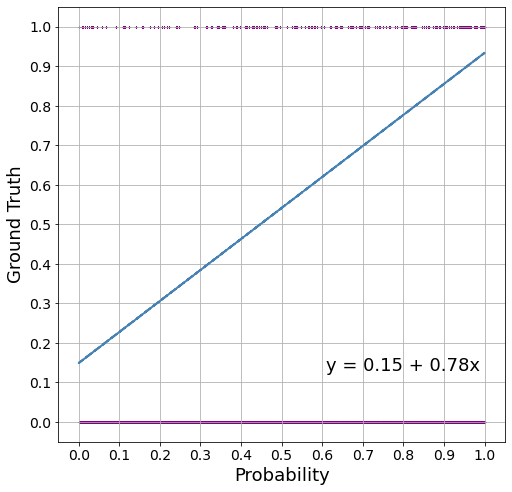

(0.1492698433556956, 0.7844997770801111)

In [24]:
plot_probability_curve(results_test)

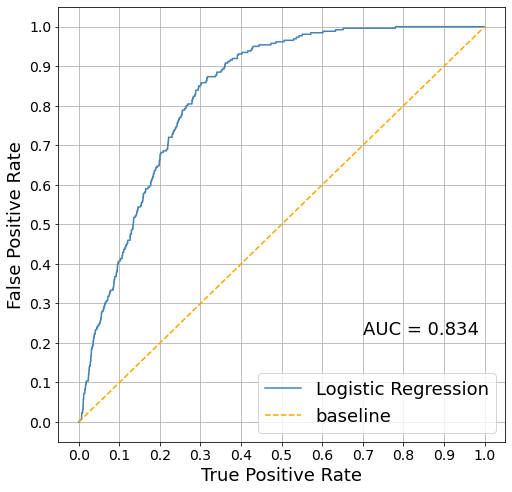

(0.302, 0.8582, 0.3134, 0.774)

In [25]:
plot_roc_curve(results_test)

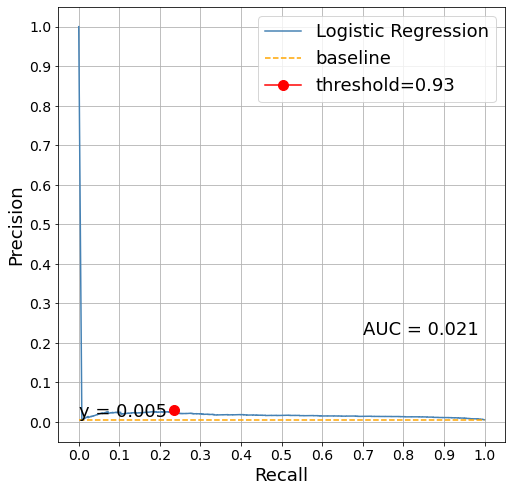

(0.2337, 0.03, 0.93, 0.0885)

In [26]:
plot_pr_curve(results_test, plot_fbeta = True)

In [27]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 100, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 28.98%
Weighted Average: 32.95%

Random Average: 17.18%
Random Weighted Average: 17.46%


In [28]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/07/2010,1,0,0.20,1,0.00 %,0.0000,20.00 %,0.2000
3,16/07/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
4,01/08/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
95,16/08/2019,9,1,1.71,9,11.11 %,0.1111,19.00 %,0.1900
96,01/09/2019,11,4,2.03,11,36.36 %,0.3636,18.45 %,0.1845
97,16/09/2019,5,1,0.94,5,20.00 %,0.2000,18.80 %,0.1880
98,01/10/2019,1,1,0.21,1,100.00 %,1.0000,21.00 %,0.2100


In [29]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,7,3,1.29,7,42.86 %,0.4286,18.43 %,0.1843
1,2011,11,0,1.76,11,0.00 %,0.0000,16.00 %,0.1600
2,2012,31,12,5.09,31,38.71 %,0.3871,16.42 %,0.1642
3,2013,28,6,5.44,28,21.43 %,0.2143,19.43 %,0.1943
4,2014,2,1,0.36,2,50.00 %,0.5000,18.00 %,0.1800
5,2015,1,0,0.14,1,0.00 %,0.0000,14.00 %,0.1400
6,2016,12,5,2.15,12,41.67 %,0.4167,17.92 %,0.1792
7,2017,16,5,2.60,16,31.25 %,0.3125,16.25 %,0.1625
8,2018,118,45,20.45,118,38.14 %,0.3814,17.33 %,0.1733
9,2019,35,9,6.30,35,25.71 %,0.2571,18.00 %,0.1800


In [30]:
report_train, report_test = classification_report_new(results_train, results_test, threshold = 0.2, beta = 4)

In [31]:
report_train

,Accuracy,Precision,Recall,F4 Score,Loss
0,0.7728,0.0249,0.9863,0.3012,0.5325


In [32]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,7.0,0.2722,0.6498,0.0026,0.5714,0.0408,0.2405
1,2011,11.0,0.5011,0.7500,0.0038,1.0000,0.0616,0.8338
2,2012,31.0,0.4842,0.7593,0.0112,1.0000,0.1616,0.8695
3,2013,28.0,0.4119,0.7955,0.0119,1.0000,0.1700,0.4622
4,2014,2.0,0.2751,0.8626,0.0013,1.0000,0.0212,0.2971
5,2015,1.0,0.3170,0.8416,0.0006,1.0000,0.0093,0.2815
6,2016,12.0,0.3138,0.8021,0.0061,0.9167,0.0943,0.2550
7,2017,16.0,0.3688,0.7851,0.0071,0.9375,0.1080,0.4405
8,2018,118.0,0.3692,0.7572,0.0489,0.8729,0.4382,0.7116
9,2019,35.0,0.3468,0.7711,0.0157,0.8857,0.2075,2.4158


In [33]:
results_test

,lau1,day,month,year,case,score
0,cibiana da cadore,16,8,2019,0,1.000000e+00
1,val da zoldo,16,7,2019,0,1.000000e+00
2,vallada agordina,16,7,2019,0,1.000000e+00
3,valle da cadore,16,7,2019,0,1.000000e+00
4,perarolo da cadore,1,6,2019,0,1.000000e+00
...,...,...,...,...,...,...
57095,schio,1,6,2013,0,1.511100e-42
57096,conco,1,6,2013,0,3.427025e-43
57097,alano da piave,1,6,2013,0,2.831862e-43
57098,paderno da grappa,1,6,2013,0,2.099026e-43


In [34]:
results_test[['lau1', 'day', 'month', 'year']].value_counts()

lau1         day  month  year
abano terme  1    6      2010    1
quero vas    16   8      2011    1
                  7      2010    1
                         2011    1
                         2012    1
                                ..
ficarolo     1    9      2016    1
                         2017    1
                         2018    1
                         2019    1
zugliano     16   10     2019    1
Length: 57100, dtype: int64

In [35]:
# results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [36]:
data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

object_cols = data_train.select_dtypes(include=['object']).columns.to_list()
removed_cols = features_to_remove

X_train = data_train.drop(columns = ['case'] + object_cols + removed_cols)
y_train = data_train['case']

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
           
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_value_counts = y_train.value_counts()
class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        
if (near_u != 0):
    if majority_class == 0:
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    elif majority_class == 1:
        nm = NearMiss(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 - near_u))}, version = 1, n_jobs = -1)

    X_train_resampled, y_train_resampled = nm.fit_resample(X_train_imputed, y_train)

    y_train_value_counts = y_train_resampled.value_counts()
    class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
    class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        

if (smote != 0):
    if majority_class == 0:
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    elif majority_class == 1:
        sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(class_0_counts * (1 + smote)), 1: class_1_counts}, n_jobs = -1, random_state = 0)

    if (near_u != 0):
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_resampled, y_train_resampled)
    else:
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)

X_train_returned = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
y_train_returned = y_train if (near_u == 0 and smote == 0) else y_train_resampled

value_counts = y_train_returned.value_counts()
non_cases = value_counts.get(key = 0) if value_counts.get(key = 0) is not None else 0
cases = value_counts.get(key = 1) if value_counts.get(key = 1) is not None else 0
        
if non_cases >= cases:
    w0 = 1
    try:
        w1 = math.ceil(non_cases/cases)
    except ZeroDivisionError:
        w1 = 10
else:
    w1 = 1
    try:
        w0 = math.ceil(cases/non_cases)
    except ZeroDivisionError:
        w0 = 10
            
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

model.fit(X_train_returned, y_train_returned)

model


LogisticRegression(class_weight={0.0: 1, 1.0: 164}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [37]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model_new.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer_new.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler_new.pkl', 'wb'))